<a href="https://colab.research.google.com/github/nikhildhavale/pythonLearning/blob/main/feedforwardamnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading MNIST dataset...
Dataset loaded successfully.

es (Shape of training imagX_train): (60000, 28, 28)
Shape of training labels (y_train): (60000,)
Shape of testing images (X_test): (10000, 28, 28)
Shape of testing labels (y_test): (10000,)

Displaying first 5 training images with their labels:


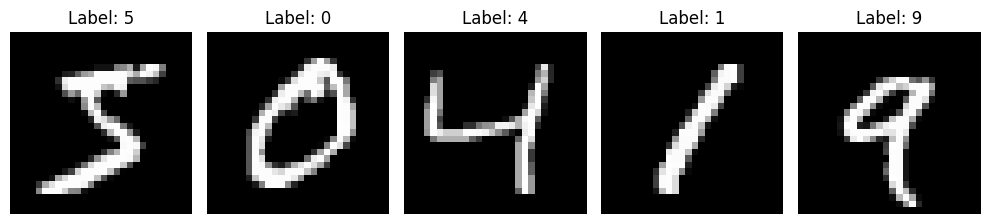

Min pixel value in training data: 0
Max pixel value in training data: 255

Normalizing image data (scaling pixel values to 0-1)...
Normalization complete.
Min pixel value after normalization: 0.0
Max pixel value after normalization: 1.0

Reshaping images from 28x28 to 1D vectors (784 features)...
Shape of flattened training images: (60000, 784)
Shape of flattened testing images: (10000, 784)

Building the neural network model...
Model built successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Compiling the model...
Model compiled.

Training the model...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8794 - loss: 0.4166 - val_accuracy: 0.9644 - val_loss: 0.1184
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9686 - loss: 0.1033 - val_accuracy: 0.9687 - val_loss: 0.0961
Epoch 3/10
 256/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9809 - loss: 0.0644

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# --- 1. Load the MNIST Dataset ---
# Keras provides a built-in function to load the MNIST dataset,
# which splits it directly into training and testing sets.
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print("Dataset loaded successfully.")

# --- 2. Explore the Data (EDA - Exploratory Data Analysis) ---
print(f"\nes (Shape of training imagX_train): {X_train.shape}") # (60000, 28, 28) -> 60,000 images, each 28x28 pixels
print(f"Shape of training labels (y_train): {y_train.shape}")   # (60000,) -> 60,000 labels (0-9)
print(f"Shape of testing images (X_test): {X_test.shape}")     # (10000, 28, 28)
print(f"Shape of testing labels (y_test): {y_test.shape}")       # (10000,)

# Display a few sample images
print("\nDisplaying first 5 training images with their labels:")
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray') # cmap='gray' for grayscale images
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off') # Hide axes for cleaner display
plt.tight_layout() # Adjust layout to prevent overlapping titles
plt.show()

# Check pixel value range
print(f"Min pixel value in training data: {X_train.min()}") # Should be 0
print(f"Max pixel value in training data: {X_train.max()}") # Should be 255

# --- 3. Preprocess the Data ---

# Normalization: Scale pixel values from 0-255 to 0-1.
# This helps neural networks learn more efficiently by preventing large input values.
print("\nNormalizing image data (scaling pixel values to 0-1)...")
X_train = X_train / 255.0
X_test = X_test / 255.0
print("Normalization complete.")
print(f"Min pixel value after normalization: {X_train.min()}")
print(f"Max pixel value after normalization: {X_train.max()}")


# Reshaping: Flatten the 28x28 images into a 1D vector of 784 pixels.
# A simple Dense (fully connected) neural network expects a 1D input for each sample.
print("\nReshaping images from 28x28 to 1D vectors (784 features)...")
X_train_flat = X_train.reshape(-1, 28 * 28) # -1 means infer the dimension based on the array length
X_test_flat = X_test.reshape(-1, 28 * 28)
print(f"Shape of flattened training images: {X_train_flat.shape}") # (60000, 784)
print(f"Shape of flattened testing images: {X_test_flat.shape}")   # (10000, 784)

# Labels (y_train, y_test) are already integers (0-9), which is compatible with
# SparseCategoricalCrossentropy loss function. If we were using CategoricalCrossentropy,
# we'd need to one-hot encode them using keras.utils.to_categorical(y, num_classes=10).
# For this example, we'll stick with SparseCategoricalCrossentropy as it's often simpler.

# --- 4. Build the Neural Network Model ---
# We'll create a simple Sequential model (a linear stack of layers).
print("\nBuilding the neural network model...")
model = keras.Sequential([
    # Input Layer: Flattens the 28x28 image into a 784-element vector.
    # This layer is implicitly handled by the first Dense layer if you specify input_shape.
    # But explicitly using Flatten makes the architecture clearer.
    keras.layers.Flatten(input_shape=(28, 28)), # Expects 28x28 input, outputs 784-element vector

    # Hidden Layer 1: A Dense (fully connected) layer with 128 neurons.
    # 'relu' (Rectified Linear Unit) is a common activation function for hidden layers.
    keras.layers.Dense(128, activation='relu'),

    # Hidden Layer 2 (Optional but often beneficial): Another Dense layer.
    keras.layers.Dense(64 , activation='relu'),

    # Output Layer: A Dense layer with 10 neurons (one for each digit 0-9).
    # 'softmax' activation converts the raw outputs into probabilities,
    # where the sum of all 10 probabilities equals 1. The neuron with the highest
    # probability is the predicted digit.
    keras.layers.Dense(10, activation='softmax')
])

print("Model built successfully.")
model.summary() # Print a summary of the model's architecture

# --- 5. Compile the Model ---
# Compiling configures the model for training.
print("\nCompiling the model...")
model.compile(
    optimizer='adam', # Adam is a popular and effective optimizer.
    loss='sparse_categorical_crossentropy', # Suitable for integer labels (0, 1, ..., 9)
    metrics=['accuracy'] # We want to track accuracy during training
)
print("Model compiled.")

# --- 6. Train the Model ---
# This is where the learning happens! The model iterates over the training data multiple times (epochs).
print("\nTraining the model...")
# Using the original X_train and y_train directly because the Flatten layer handles reshaping
history = model.fit(X_train, y_train,
                    epochs=10,        # Number of times to iterate over the entire training dataset
                    batch_size=32,    # Number of samples per gradient update
                    validation_data=(X_test, y_test) # Data to evaluate on after each epoch (for monitoring)
                   )
print("Model training complete.")

# --- 7. Evaluate the Model ---
# Evaluate the model's performance on the unseen test data.
print("\nEvaluating the model on the test dataset...")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# --- 8. Visualize Training History ---
# Plotting loss and accuracy over epochs helps understand training progress and diagnose overfitting.
print("\nPlotting training history...")
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 9. Make Predictions ---
# Let's see some predictions on a few test images.
print("\nMaking predictions on a few test images...")
predictions = model.predict(X_test)

plt.figure(figsize=(12, 8))
for i in range(10): # Display first 10 test images
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    predicted_label = np.argmax(predictions[i]) # Get the index of the highest probability
    true_label = y_test[i]
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Display a single challenging prediction (e.g., where model might be wrong)
# Find an example where the model predicted incorrectly for visualization
incorrect_indices = np.where(np.argmax(predictions, axis=1) != y_test)[0]
if len(incorrect_indices) > 0:
    first_incorrect_idx = incorrect_indices[0]
    plt.figure(figsize=(4, 4))
    plt.imshow(X_test[first_incorrect_idx], cmap='gray')
    predicted_label = np.argmax(predictions[first_incorrect_idx])
    true_label = y_test[first_incorrect_idx]
    plt.title(f"Example of Incorrect Prediction\nTrue: {true_label}, Predicted: {predicted_label}", color='red')
    plt.axis('off')
    plt.show()
else:
    print("All predictions were correct on the sample! (This is unlikely for the first 10, but great if true!)")

# --- 10. Save and Load the Model (Optional) ---
# It's good practice to save your trained model so you don't have to retrain it every time.
model_filename = 'mnist_digit_classifier.keras' # Recommended format for Keras since TF 2.6
print(f"\nSaving the model to {model_filename}...")
model.save(model_filename)
print("Model saved.")

# To load the model later:
# loaded_model = keras.models.load_model(model_filename)
# print(f"Model loaded from {model_filename}.")
# # You can then use loaded_model.predict() or loaded_model.evaluate()"
